In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern, mismo look que LaTeX

In [13]:
# Read the file: one line per instance
with open("../data/gillespie_burst_poisson.txt", "r") as f: #all the analysis are the same except the file name, so we can change it here to analyze different files
    lines = f.readlines()

# Parse each line into its own (time, mRNA, protein) arrays
time_list, protein_list = [], []
for line in lines:
    values = np.array(line.split(), dtype=float)
    time_list.append(values[0::2])
    protein_list.append(values[1::2])


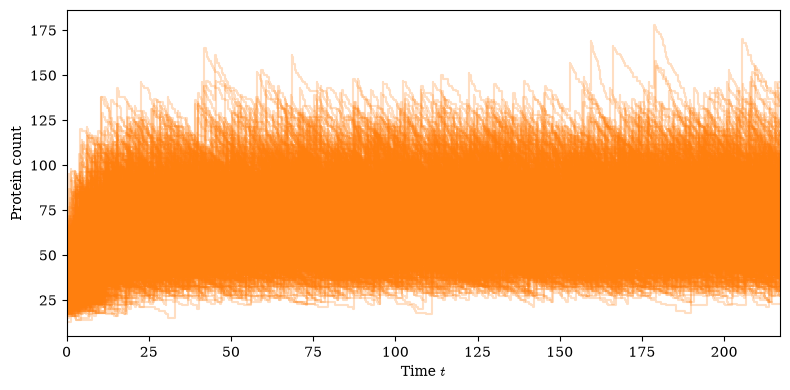

In [14]:

fig, ax = plt.subplots(figsize=(8,4))

for i in range(len(lines)):
    ax.step(time_list[i], protein_list[i], where='post', color='tab:orange', alpha=0.25)

ax.set_ylabel(r"Protein count")
ax.set_xlabel(r"Time $t$")

ax.set_xlim(0, 217)
plt.tight_layout()
#plt.savefig("../figures/50_runs.pdf")
plt.show()

In [15]:
#The dimensions are heterogeneous, so we need to fill the data into a common time grid to calculate mean and standard deviation.
#to do this we coarse grain the time grid to a fixed number of time points.
number_of_time_points = 10000
time_coarse = np.linspace(0, 217, number_of_time_points) #coarse grained time grid
resampled_protein = np.zeros((len(lines), number_of_time_points))

#and we fill the resampled array using the last known value for each time point (step function behavior).

for i in range(len(lines)):
    resampled_protein[i] = protein_list[i][np.searchsorted(time_list[i], time_coarse, side='right') - 1]

In [16]:
#Now with common times we can calculate the mean and standard deviation across all simulations for each time point.
mean_protein = np.mean(resampled_protein, axis=0)
std_protein = np.std(resampled_protein, axis=0)

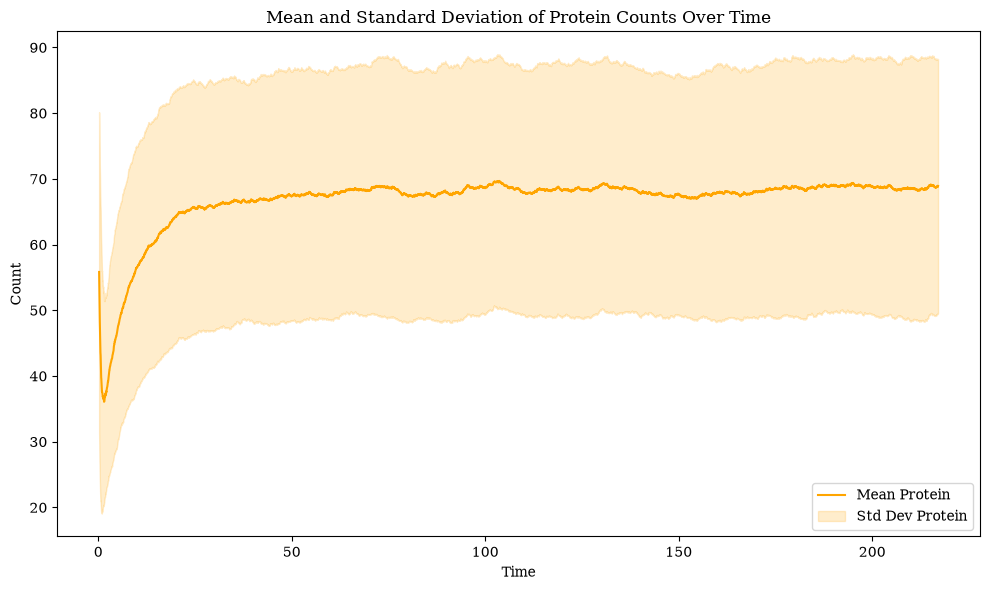

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(time_coarse[10:], mean_protein[10:], label='Mean Protein', color='orange')
plt.fill_between(time_coarse[10:], (mean_protein - std_protein)[10:], (mean_protein + std_protein)[10:], color='orange', alpha=0.2, label='Std Dev Protein')
plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Mean and Standard Deviation of Protein Counts Over Time')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
print("protein mean: " + str(mean_protein[-1]))
print("protein std: " + str(std_protein[-1]))


protein mean: 68.929
protein std: 19.33701008429173
